In [9]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv(
    
    "/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/data 2.csv", 
)
df.head(50)

,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
0,Colombia,2006,6.025,9.277,0.910,65.22,0.805,-0.015,0.808,0.800,0.326
1,Colombia,2007,6.138,9.330,0.894,65.34,0.786,-0.040,0.860,0.808,0.287
2,Colombia,2008,6.168,9.351,0.880,65.46,0.795,-0.042,0.763,0.803,0.307
3,Colombia,2009,6.272,9.351,0.886,65.58,0.757,-0.055,0.837,0.843,0.273
4,Colombia,2010,6.408,9.384,0.893,65.70,0.816,-0.050,0.815,0.831,0.265
5,Colombia,2011,6.464,9.442,0.904,65.92,0.811,-0.073,0.847,0.832,0.286
6,Colombia,2012,6.375,9.471,0.914,66.14,0.828,-0.009,0.868,0.846,0.294
7,Colombia,2013,6.607,9.512,0.901,66.36,0.841,-0.071,0.898,0.851,0.278
8,Colombia,2014,6.449,9.546,0.907,66.58,0.801,-0.090,0.887,0.847,0.278
9,Colombia,2015,6.388,9.564,0.890,66.80,0.791,-0.100,0.843,0.839,0.292


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country name                      115 non-null    object 
 1   year                              115 non-null    int64  
 2   Life Ladder                       115 non-null    float64
 3   Log GDP per capita                115 non-null    float64
 4   Social support                    113 non-null    float64
 5   Healthy life expectancy at birth  115 non-null    float64
 6   Freedom to make life choices      112 non-null    float64
 7   Generosity                        113 non-null    float64
 8   Perceptions of corruption         110 non-null    float64
 9   Positive affect                   114 non-null    float64
 10  Negative affect                   114 non-null    float64
dtypes: float64(9), int64(1), object(1)
memory usage: 10.0+ KB


In [12]:
print(df.columns.tolist())
df.columns = df.columns.str.strip()
print(df.index.names)
df.reset_index(inplace=True)
print(df.isnull().sum())
data = df.dropna() 
print(df["year"].unique())
print(len(df["year"].unique()))

['Country name', 'year', 'Life Ladder', 'Log GDP per capita', 'Social support', 'Healthy life expectancy at birth', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption', 'Positive affect', 'Negative affect']
[None]
index                               0
Country name                        0
year                                0
Life Ladder                         0
Log GDP per capita                  0
Social support                      2
Healthy life expectancy at birth    0
Freedom to make life choices        3
Generosity                          2
Perceptions of corruption           5
Positive affect                     1
Negative affect                     1
dtype: int64
[2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019
 2020]
15


In [22]:
rename_columns = {
    'Country name': 'country',
    'year': 'year',
    'Life Ladder': 'life_ladder',
    'Log GDP per capita': 'log_gdp',
    'Social support': 'social_support',
    'Healthy life expectancy at birth': 'life_expectancy',
    'Freedom to make life choices': 'freedom',
    'Generosity': 'generosity',
    'Perceptions of corruption': 'corruption',
    'Positive affect': 'positive_affect',
    'Negative affect': 'negative_affect'
}

df.rename(columns=rename_columns, inplace=True)

print(data.columns)


Index(['index', 'country', 'year', 'life_ladder', 'log_gdp', 'social_support',
       'life_expectancy', 'freedom', 'generosity', 'corruption',
       'positive_affect', 'negative_affect'],
      dtype='object')


# STATISCAL DECRIPTION

In [23]:
description = df.describe()
print(description)

            index         year  life_ladder     log_gdp  social_support  \
count  115.000000   115.000000   115.000000  115.000000      113.000000   
mean    57.000000  2012.852174     5.816504    9.563539        0.872549   
std     33.341666     4.290429     1.133276    0.954029        0.058368   
min      0.000000  2006.000000     2.694000    7.461000        0.717000   
25%     28.500000  2009.000000     5.084500    9.134500        0.839000   
50%     57.000000  2013.000000     5.914000    9.546000        0.882000   
75%     85.500000  2016.500000     6.834000   10.386000        0.910000   
max    114.000000  2020.000000     7.604000   11.043000        0.987000   

       life_expectancy     freedom  generosity  corruption  positive_affect  \
count       115.000000  112.000000  113.000000  110.000000       114.000000   
mean         63.533043    0.808063    0.080708    0.751355         0.788798   
std           7.722663    0.118386    0.188374    0.200525         0.075891   
min     

$$
close_{it} = \beta_0 + \beta_1 high_{it} + \beta_2 low_{it} + \beta_3 open_{it} + \beta_4 index_{it} + \epsilon_{it} 
$$

# OLS REGRESSION RESULT

In [25]:
import statsmodels.formula.api as smf
model = smf.ols(
    formula="life_ladder ~ log_gdp + social_support + life_expectancy + freedom + generosity + corruption",
    data=df
)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:            life_ladder   R-squared:                       0.891
Model:                            OLS   Adj. R-squared:                  0.884
Method:                 Least Squares   F-statistic:                     137.4
Date:                Sun, 08 Dec 2024   Prob (F-statistic):           2.87e-46
Time:                        10:37:55   Log-Likelihood:                -47.413
No. Observations:                 108   AIC:                             108.8
Df Residuals:                     101   BIC:                             127.6
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -7.6358      0.876     

# FIXED EFFECTS

In [26]:
from linearmodels.panel import PanelOLS

df = df.set_index(['country', 'year'])

y = df['life_ladder']
X = df[['log_gdp', 'social_support', 'life_expectancy', 'freedom', 'generosity', 'corruption']]

X = X.assign(constant=1)

model = PanelOLS(y, X, entity_effects=True)

fe_results = model.fit()

print(fe_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:            life_ladder   R-squared:                        0.2327
Estimator:                   PanelOLS   R-squared (Between):              0.6587
No. Observations:                 108   R-squared (Within):               0.2327
Date:                Sun, Dec 08 2024   R-squared (Overall):              0.6234
Time:                        10:40:31   Log-likelihood                   -26.326
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      4.7515
Entities:                           8   P-value                           0.0003
Avg Obs:                       13.500   Distribution:                    F(6,94)
Min Obs:                      10.0000                                           
Max Obs:                       15.000   F-statistic (robust):             4.7515
                            

/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/myenv/lib/python3.9/site-packages/linearmodels/panel/model.py:1260: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


# RANDOM EFFECTS

In [27]:
from linearmodels.panel import PanelOLS
from linearmodels.panel import RandomEffects

y = df['life_ladder']
X = df[['log_gdp', 'social_support', 'life_expectancy', 'freedom', 'generosity', 'corruption']]

X = X.assign(constant=1)

model = PanelOLS(y, X, entity_effects=True)
model = RandomEffects(y, X)
re_results = model.fit()

print(re_results.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:            life_ladder   R-squared:                        0.8908
Estimator:              RandomEffects   R-squared (Between):              0.9928
No. Observations:                 108   R-squared (Within):              -0.0660
Date:                Sun, Dec 08 2024   R-squared (Overall):              0.8908
Time:                        10:41:03   Log-likelihood                   -47.413
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      137.36
Entities:                           8   P-value                           0.0000
Avg Obs:                       13.500   Distribution:                   F(6,101)
Min Obs:                      10.0000                                           
Max Obs:                       15.000   F-statistic (robust):             137.36
                            

/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/myenv/lib/python3.9/site-packages/linearmodels/panel/model.py:1260: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/myenv/lib/python3.9/site-packages/linearmodels/panel/model.py:2759: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


# HAUSMAN TEST

In [28]:
from linearmodels.panel import PanelOLS, compare
from linearmodels.panel import compare

hausman_test = compare({'Fixed Effects': fe_results, 'Random Effects': re_results})

print(hausman_test)

                     Model Comparison                    
                          Fixed Effects    Random Effects
---------------------------------------------------------
Dep. Variable               life_ladder       life_ladder
Estimator                      PanelOLS     RandomEffects
No. Observations                    108               108
Cov. Est.                    Unadjusted        Unadjusted
R-squared                        0.2327            0.8908
R-Squared (Within)               0.2327           -0.0660
R-Squared (Between)              0.6587            0.9928
R-Squared (Overall)              0.6234            0.8908
F-statistic                      4.7515            137.36
P-value (F-stat)                 0.0003            0.0000
=====================     =============   ===============
log_gdp                          0.7014            0.3751
                               (1.9330)          (5.5608)
social_support                   4.0997            6.9077
              

/var/folders/2w/0ds979vs33z3m70t85hh_cp00000gn/T/ipykernel_11084/4124590727.py:12: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  'year': pd.date_range(start='2006-01-01', periods=15, freq='Y'),


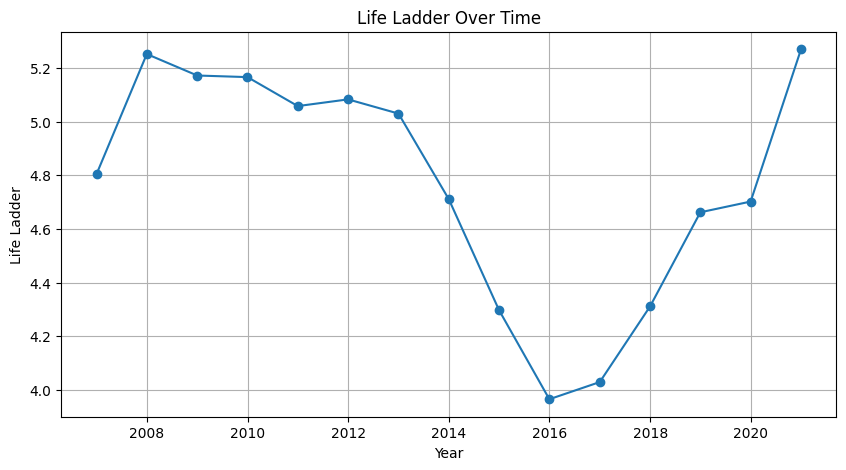

/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/myenv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/myenv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/myenv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/var/folders/2w/0ds979vs33z3m70t85hh_cp00000gn/T/ipykernel_11084/4124590727.py:46: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  plt.plot(pd.date_range(start='2021', periods=5, freq='Y'), forecast, marker='o', 

                               SARIMAX Results                                
Dep. Variable:            life_ladder   No. Observations:                   15
Model:                 ARIMA(1, 1, 1)   Log Likelihood                  -0.864
Date:                Sun, 08 Dec 2024   AIC                              7.728
Time:                        10:44:03   BIC                              9.645
Sample:                    12-31-2006   HQIC                             7.551
                         - 12-31-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5462      0.583      0.937      0.349      -0.597       1.689
ma.L1         -0.0103      0.744     -0.014      0.989      -1.468       1.447
sigma2         0.0646      0.039      1.650      0.0

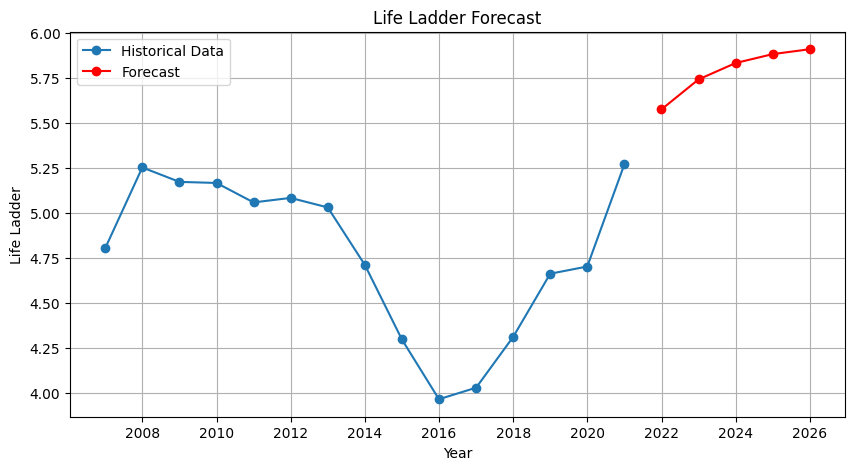

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error

# Load your data
# For this example, let's create a sample time series data
# Replace this with your actual data loading method
data = {
    'year': pd.date_range(start='2006-01-01', periods=15, freq='Y'),
    'life_ladder': [4.804, 5.252, 5.172, 5.166, 5.058, 5.083, 5.030, 4.711, 4.297, 3.965, 4.029, 4.311, 4.662, 4.702, 5.270]
}
df = pd.DataFrame(data)
df.set_index('year', inplace=True)

# Plot the time series
plt.figure(figsize=(10, 5))
plt.plot(df, marker='o')
plt.title('Life Ladder Over Time')
plt.xlabel('Year')
plt.ylabel('Life Ladder')
plt.grid()
plt.show()

# Check for stationarity
# You can use the Augmented Dickey-Fuller test here if needed

# Fit the ARIMA model
# Here we choose (p, d, q) parameters; you may need to adjust these
model = ARIMA(df['life_ladder'], order=(1, 1, 1))
model_fit = model.fit()

# Print the summary of the model
print(model_fit.summary())

# Make predictions
forecast = model_fit.forecast(steps=5)  # Forecasting the next 5 years
print("Forecasted Life Ladder for next 5 years:")
print(forecast)

# Plot the forecast
plt.figure(figsize=(10, 5))
plt.plot(df, marker='o', label='Historical Data')
plt.plot(pd.date_range(start='2021', periods=5, freq='Y'), forecast, marker='o', color='red', label='Forecast')
plt.title('Life Ladder Forecast')
plt.xlabel('Year')
plt.ylabel('Life Ladder')
plt.legend()
plt.grid()
plt.show()

# Calculate and print the mean squared error if you have actual future values
# actual_values = [your actual future values here]
# mse = mean_squared_error(actual_values, forecast)
# print(f'Mean Squared Error: {mse}')